In [ ]:
from google.colab import files
uploaded = files.upload()

Saving shopping_behavior_updated.csv to shopping_behavior_updated.csv


# Data Loading


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("shopping_behavior_updated.csv")

# Preview data
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


# Data Understanding


In [ ]:
# Struktur data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [ ]:
# Statistik deskriptif
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [ ]:
# Missing values
df.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


In [ ]:
# Duplicate check
df.duplicated().sum()

np.int64(0)

In [ ]:
# Unique values tiap kolom kategorikal
for col in df.select_dtypes(include='object'):
    print(col)
    print(df[col].unique())
    print("-----")

Gender
['Male' 'Female']
-----
Item Purchased
['Blouse' 'Sweater' 'Jeans' 'Sandals' 'Sneakers' 'Shirt' 'Shorts' 'Coat'
 'Handbag' 'Shoes' 'Dress' 'Skirt' 'Sunglasses' 'Pants' 'Jacket' 'Hoodie'
 'Jewelry' 'T-shirt' 'Scarf' 'Hat' 'Socks' 'Backpack' 'Belt' 'Boots'
 'Gloves']
-----
Category
['Clothing' 'Footwear' 'Outerwear' 'Accessories']
-----
Location
['Kentucky' 'Maine' 'Massachusetts' 'Rhode Island' 'Oregon' 'Wyoming'
 'Montana' 'Louisiana' 'West Virginia' 'Missouri' 'Arkansas' 'Hawaii'
 'Delaware' 'New Hampshire' 'New York' 'Alabama' 'Mississippi'
 'North Carolina' 'California' 'Oklahoma' 'Florida' 'Texas' 'Nevada'
 'Kansas' 'Colorado' 'North Dakota' 'Illinois' 'Indiana' 'Arizona'
 'Alaska' 'Tennessee' 'Ohio' 'New Jersey' 'Maryland' 'Vermont'
 'New Mexico' 'South Carolina' 'Idaho' 'Pennsylvania' 'Connecticut' 'Utah'
 'Virginia' 'Georgia' 'Nebraska' 'Iowa' 'South Dakota' 'Minnesota'
 'Washington' 'Wisconsin' 'Michigan']
-----
Size
['L' 'S' 'M' 'XL']
-----
Color
['Gray' 'Maroon' 'Turqu

Age: 0 outliers detected
Purchase Amount (USD): 0 outliers detected
Review Rating: 0 outliers detected
Previous Purchases: 0 outliers detected


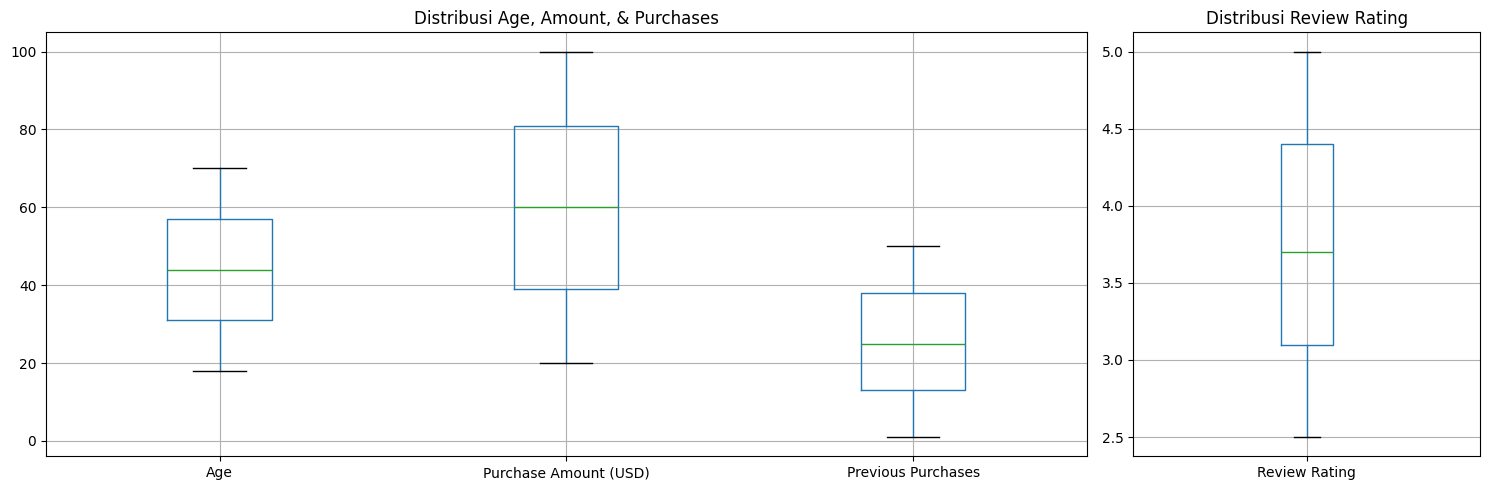

In [ ]:
# Outlier Detection
numeric_cols = ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers detected")

cols_large = ['Age', 'Purchase Amount (USD)', 'Previous Purchases']
col_small = ['Review Rating']

fig, ax = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [3, 1]})

# Boxplot untuk kolom dengan skala besar
df[cols_large].boxplot(ax=ax[0])
ax[0].set_title("Distribusi Age, Amount, & Purchases")

# Boxplot khusus Review Rating (skala kecil)
df[col_small].boxplot(ax=ax[1])
ax[1].set_title("Distribusi Review Rating")

plt.tight_layout()
plt.show()

# Data Cleaning

In [ ]:
# Handling Data Inconsistency
mapping = {
    'Every 3 Months': 'Quarterly',
    'Bi-Weekly': 'Fortnightly'
}

df['Frequency of Purchases'] = df['Frequency of Purchases'].replace(mapping)

#  Drop irrelevant columns
columns_to_drop = ["Customer ID", "Color", "Size"]
df = df.drop(columns=columns_to_drop)

#  Encoding Yes/No
yes_no_cols = ['Subscription Status','Discount Applied','Promo Code Used']

for col in yes_no_cols:
    df[col] = df[col].map({'Yes':1,'No':0})

# Data Validation

In [ ]:
# Check missing & duplicate again
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

# Logical validation
def check_logic(df):
    print("--- Data Validation ---")

    print("Invalid Age:", len(df[(df['Age'] < 18) | (df['Age'] > 100)]))
    print("Invalid Purchase Amount:", len(df[df['Purchase Amount (USD)'] <= 0]))
    print("Invalid Rating:", len(df[(df['Review Rating'] < 1) | (df['Review Rating'] > 5)]))
    print("Invalid Previous Purchases:", len(df[df['Previous Purchases'] < 0]))

check_logic(df)

Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64
Duplicates: 0
--- Data Validation ---
Invalid Age: 0
Invalid Purchase Amount: 0
Invalid Rating: 0
Invalid Previous Purchases: 0


In [ ]:
from scipy import stats

print("--- Z-Score Outlier Check ---")

for col in numeric_cols:
    z_scores = np.abs(stats.zscore(df[col]))
    outliers = df[z_scores > 3]

    print(f"{col}: {len(outliers)} outliers")

--- Z-Score Outlier Check ---
Age: 0 outliers
Purchase Amount (USD): 0 outliers
Review Rating: 0 outliers
Previous Purchases: 0 outliers


In [ ]:
summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Duplicate Rows": df.duplicated().sum(),
    "Unique Values": df.nunique(),
    "Data Type": df.dtypes
})

summary

,Missing Values,Duplicate Rows,Unique Values,Data Type
Age,0,0,53,int64
Gender,0,0,2,object
Item Purchased,0,0,25,object
Category,0,0,4,object
Purchase Amount (USD),0,0,81,int64
Location,0,0,50,object
Season,0,0,4,object
Review Rating,0,0,26,float64
Subscription Status,0,0,2,int64
Shipping Type,0,0,6,object


# Feature Engineering

In [ ]:
# Age Group
bins = [18, 30, 50, 100]
labels = ['Young Adult', 'Adult', 'Senior']

df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# --- Purchase Frequency Tier ---
frequency_tier_map = {
    'Weekly': 'High',
    'Fortnightly': 'High',
    'Monthly': 'Medium',
    'Quarterly': 'Low',
    'Annually': 'Low'
}

df['Purchase Frequency Tier'] = df['Frequency of Purchases'].map(frequency_tier_map)

# Preview
df[['Age', 'Age Group', 'Frequency of Purchases', 'Purchase Frequency Tier']].head()

,Age,Age Group,Frequency of Purchases,Purchase Frequency Tier
0,55,Senior,Fortnightly,High
1,19,Young Adult,Fortnightly,High
2,50,Senior,Weekly,High
3,21,Young Adult,Weekly,High
4,45,Adult,Annually,Low


# DF to CSV

In [ ]:
df.to_csv("shopping_behavior_cleaned.csv", index=False)

# EDA

## Numeric Statistic

In [ ]:
print("--- Numerical Statistics ---")
df.describe()

--- Numerical Statistics ---


,Age,Purchase Amount (USD),Review Rating,Subscription Status,Discount Applied,Promo Code Used,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,44.068462,59.764359,3.749949,0.270000,0.430000,0.430000,25.351538
std,15.207589,23.685392,0.716223,0.444016,0.495139,0.495139,14.447125
min,18.000000,20.000000,2.500000,0.000000,0.000000,0.000000,1.000000
25%,31.000000,39.000000,3.100000,0.000000,0.000000,0.000000,13.000000
50%,44.000000,60.000000,3.700000,0.000000,0.000000,0.000000,25.000000
75%,57.000000,81.000000,4.400000,1.000000,1.000000,1.000000,38.000000
max,70.000000,100.000000,5.000000,1.000000,1.000000,1.000000,50.000000


## Categorical Statistic

In [ ]:
print("--- Categorical Statistics ---")
df.describe(include=['object', 'category'])

--- Categorical Statistics ---


,Gender,Item Purchased,Category,Location,Season,Shipping Type,Payment Method,Frequency of Purchases,Age Group,Purchase Frequency Tier
count,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900
unique,2,25,4,50,4,6,6,5,3,3
top,Male,Blouse,Clothing,Montana,Spring,Free Shipping,PayPal,Quarterly,Senior,Low
freq,2652,171,1737,96,999,675,677,1147,1559,1719


#Distribusi data


In [ ]:
# --- GLOBAL VISUALIZATION SETTINGS ---
plt.style.use('default')
sns.set_theme(style="white")

# Standar Ukuran & Warna
TITLE_SIZE = 14
LABEL_SIZE = 11
MAIN_COLOR = "#4E79A7"
PALETTE_COLOR = "Blues_d"

plt.rcParams.update({
    'figure.figsize': (8, 4),
    'axes.titlesize': TITLE_SIZE,
    'axes.labelsize': LABEL_SIZE,
    'xtick.labelsize': LABEL_SIZE,
    'ytick.labelsize': LABEL_SIZE,
    'axes.titlepad': 25,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False
})

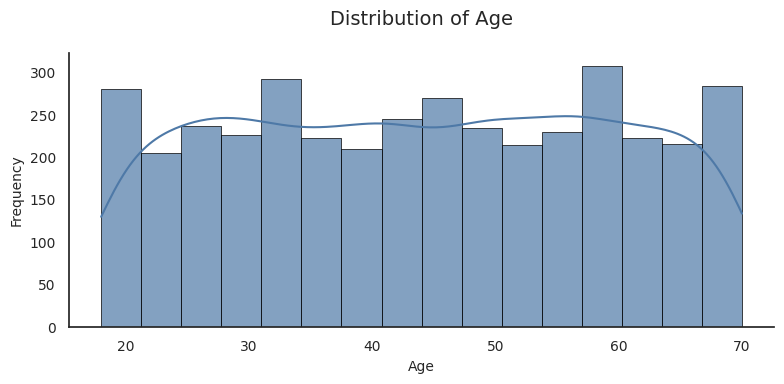

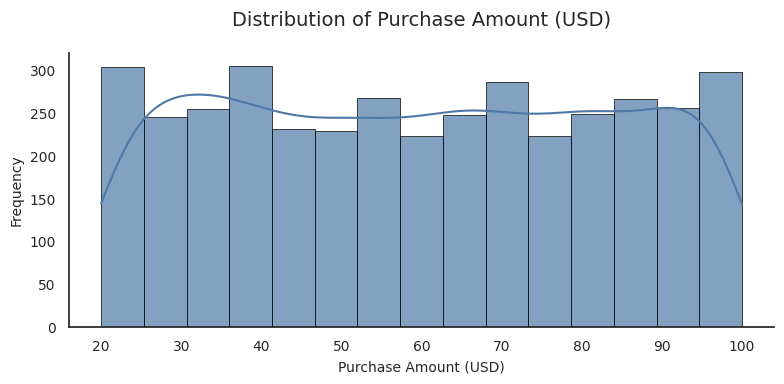

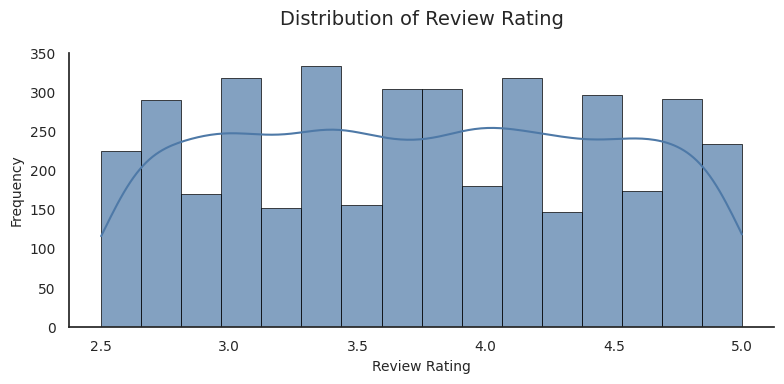

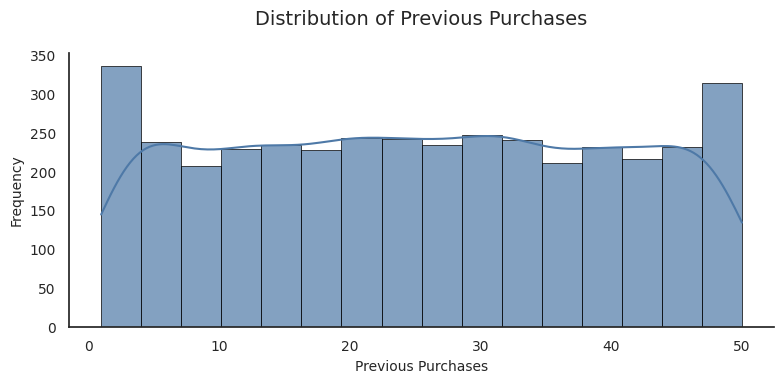

In [ ]:

for col in num_cols:
    plt.figure(figsize=(8, 4))
    ax = sns.histplot(
        df[col],
        kde=True,
        color=MAIN_COLOR,
        edgecolor='black',
        linewidth=0.5,
        alpha=0.7
    )

    plt.title(f'Distribution of {col}', pad=20, fontsize=TITLE_SIZE)
    plt.xlabel(col, fontsize=LABEL_SIZE)
    plt.ylabel('Frequency', fontsize=LABEL_SIZE)
    plt.ylim(0, None)
    plt.grid(False)
    sns.despine()

    plt.tight_layout()
    plt.show()

# Boxplot Analysis

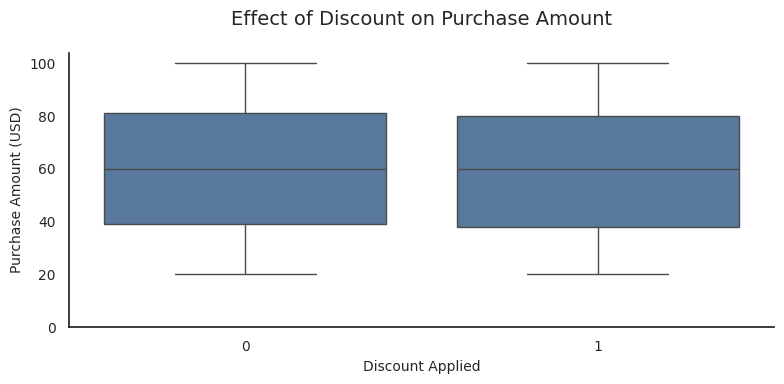

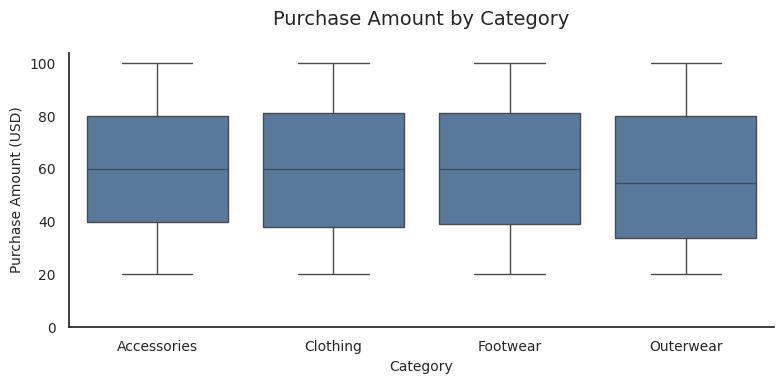

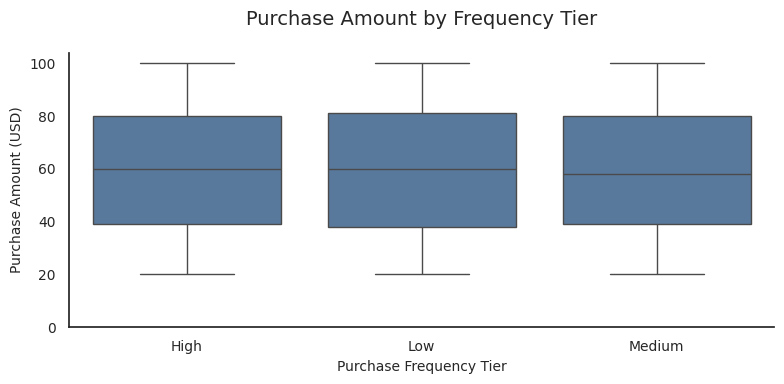

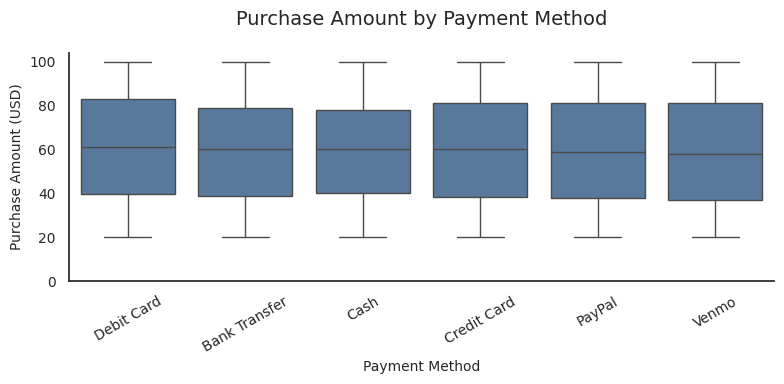

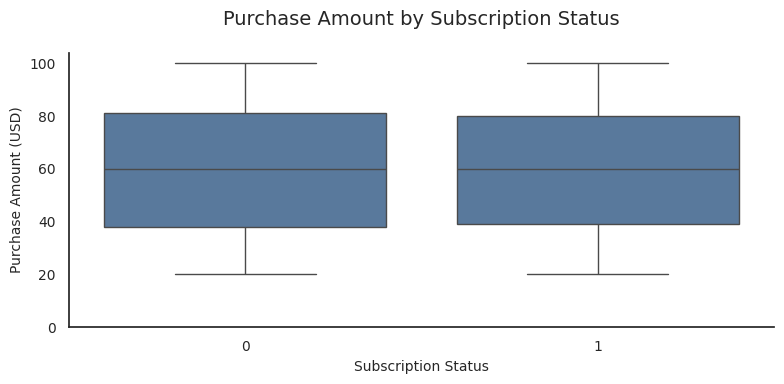

In [ ]:

MAIN_COLOR = "#4E79A7"
TITLE_PAD = 20

def finalize_boxplot(ax, title):
    ax.set_title(title, pad=TITLE_PAD, fontsize=TITLE_SIZE)
    ax.set_ylim(0, None)
    ax.set_xlabel(ax.get_xlabel(), fontsize=LABEL_SIZE)
    ax.set_ylabel(ax.get_ylabel(), fontsize=LABEL_SIZE)
    sns.despine()
    plt.tight_layout()

# 1. Discount Effect
plt.figure(figsize=(8, 4))
ax = sns.boxplot(data=df, x='Discount Applied', y='Purchase Amount (USD)', color=MAIN_COLOR, fliersize=3)
finalize_boxplot(ax, 'Effect of Discount on Purchase Amount')
plt.show()

# 2. Category Effect
cat_order = df.groupby('Category')['Purchase Amount (USD)'].median().sort_values(ascending=False).index

plt.figure(figsize=(8, 4))
ax = sns.boxplot(data=df, x='Category', y='Purchase Amount (USD)', color=MAIN_COLOR, order=cat_order, fliersize=3)
finalize_boxplot(ax, 'Purchase Amount by Category')
plt.show()

# 3. Frequency Effect
plt.figure(figsize=(8, 4))
ax = sns.boxplot(data=df, x='Purchase Frequency Tier', y='Purchase Amount (USD)', color=MAIN_COLOR, fliersize=3)
finalize_boxplot(ax, 'Purchase Amount by Frequency Tier')
plt.show()

# 4. Payment Method
pay_order = df.groupby('Payment Method')['Purchase Amount (USD)'].median().sort_values(ascending=False).index

plt.figure(figsize=(8, 4))
ax = sns.boxplot(data=df, x='Payment Method', y='Purchase Amount (USD)', color=MAIN_COLOR, order=pay_order, fliersize=3)
plt.xticks(rotation=30) # Rotasi sedikit agar mudah dibaca
finalize_boxplot(ax, 'Purchase Amount by Payment Method')
plt.show()

# 5. Subscription Status
plt.figure(figsize=(8, 4))
ax = sns.boxplot(data=df, x='Subscription Status', y='Purchase Amount (USD)', color=MAIN_COLOR, fliersize=3)
finalize_boxplot(ax, 'Purchase Amount by Subscription Status')
plt.show()

#Correlation Analysis

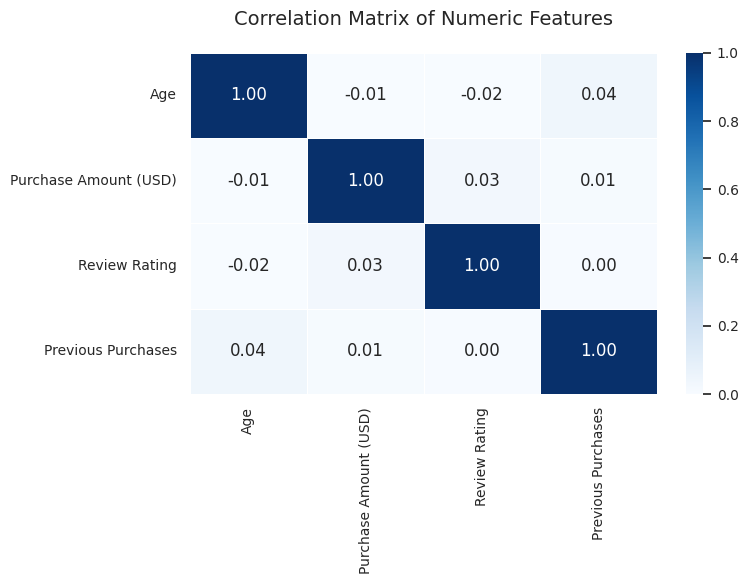

In [ ]:
plt.figure(figsize=(8, 6))

correlation_matrix = df[num_cols].corr()
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='Blues',
    fmt=".2f",
    cbar=True,
    linewidths=0.5,
    vmin=0,
    vmax=1
)

plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

# Additional Analysis

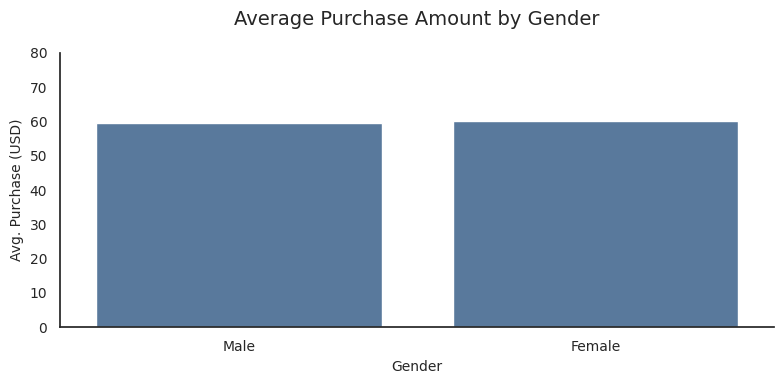

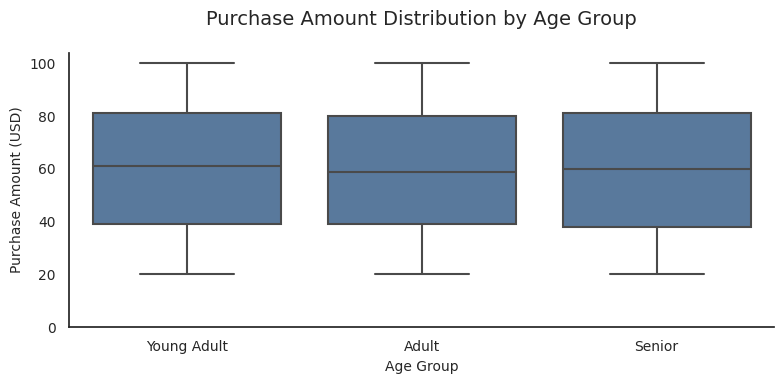

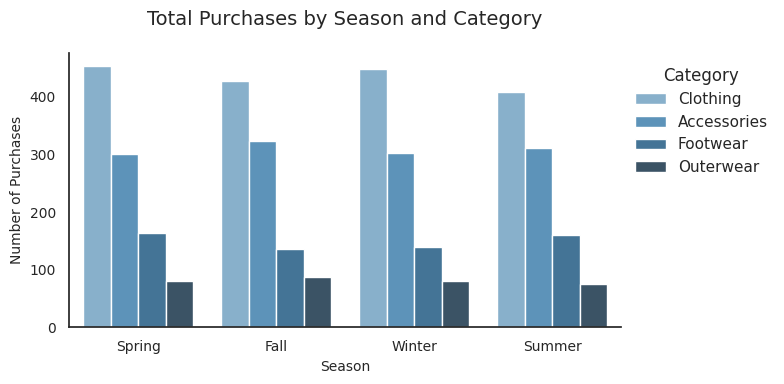

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="white")
COLOR_MAIN = "#4E79A7"
COLOR_PALETTE = "Blues_d"
TITLE_SIZE = 14
LABEL_SIZE = 10


plt.rcParams.update({
    'axes.titlesize': TITLE_SIZE,
    'axes.labelsize': LABEL_SIZE,
    'xtick.labelsize': LABEL_SIZE,
    'ytick.labelsize': LABEL_SIZE,
    'axes.titlepad': 20,
    'axes.spines.top': False,
    'axes.spines.right': False
})

# 1. Gender vs Spending (Bar Chart)
plt.figure(figsize=(8, 4))
ax1 = sns.barplot(
    data=df,
    x='Gender',
    y='Purchase Amount (USD)',
    estimator=np.mean,
    color=COLOR_MAIN,
    errorbar=None
)

plt.title('Average Purchase Amount by Gender')
plt.xlabel('Gender')
plt.ylabel('Avg. Purchase (USD)')
plt.ylim(0, df['Purchase Amount (USD)'].max() * 0.8)
sns.despine()
plt.tight_layout()
plt.show()


# 2. Age Group vs Purchase (Box Plot)
plt.figure(figsize=(8, 4))
sns.boxplot(
    data=df,
    x='Age Group',
    y='Purchase Amount (USD)',
    color=COLOR_MAIN,
    fliersize=3,
    linewidth=1.5
)

plt.title('Purchase Amount Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Purchase Amount (USD)')
plt.ylim(0, None)
sns.despine()
plt.tight_layout()
plt.show()


# 3. Season Trend (Count Plot)
season_order = df['Season'].value_counts().index
category_order = df['Category'].value_counts().index

plt.figure()
sns.countplot(
    data=df,
    x='Season',
    hue='Category',
    order=season_order,
    hue_order=category_order,
    palette=PALETTE_COLOR
)

plt.title('Total Purchases by Season and Category')
plt.ylabel('Number of Purchases')
plt.legend(title='Category', frameon=False, bbox_to_anchor=(1, 1))
plt.ylim(0, None)
plt.tight_layout()
plt.show()

# Variability

In [ ]:
print("--- Variability Analysis ---")

for col in ['Age', 'Purchase Amount (USD)', 'Review Rating']:
    std_val = df[col].std()
    range_val = df[col].max() - df[col].min()

    print(f"{col}: Std = {std_val:.2f}, Range = {range_val:.2f}")

--- Variability Analysis ---
Age: Std = 15.21, Range = 52.00
Purchase Amount (USD): Std = 23.69, Range = 80.00
Review Rating: Std = 0.72, Range = 2.50


# Insight

1️⃣ Gender Spending Disparity (High-Value Market Identification)
👉 Insight: Meskipun distribusi usia (Histogram 1) terlihat merata di seluruh rentang 20-70 tahun, terdapat perbedaan Total Spend yang sangat kontras antara Male dan Female (Grafik Bar). Pengeluaran pria hampir dua kali lipat (2x) lebih besar dibandingkan wanita.

Value: Strategi Customer Acquisition Cost (CAC) harus dibedakan. Jika tujuannya adalah revenue cepat, fokuskan budget iklan pada segmen pria. Namun, jika ingin ekspansi, segmen wanita adalah "blue ocean" yang perlu di-treatment ulang cara pemasarannya karena penetrasinya masih rendah.

2️⃣ Age-Agnostic Spending Behavior (The "Uniformity" Pattern)
👉 Insight: Berdasarkan Boxplot (Purchase Amount by Age Group) dan Heatmap (korelasi Age vs Purchase Amount = -0.01), daya beli customer kamu tidak dipengaruhi oleh usia. Baik Young Adult, Adult, maupun Senior memiliki median belanja yang hampir identik di angka ~$60.

Value: Jangan terjebak membuat kampanye produk yang terlalu tersegmentasi berdasarkan umur (misal: "produk khusus anak muda"). Data menunjukkan bahwa daya beli mereka seragam. Kamu bisa menghemat biaya kreatif dengan menggunakan pesan pemasaran yang lebih universal namun fokus pada value produk.

3️⃣ Low-Retention Correlation (The "First-Timer" Trap)
👉 Insight: Melihat Heatmap, korelasi antara Previous Purchases dengan Purchase Amount sangat lemah (0.01). Ini adalah red flag. Artinya, orang yang sudah sering belanja di tempatmu (loyal) tidak lantas berbelanja dalam jumlah yang lebih besar dibanding orang baru.

Value: Kamu punya masalah pada Upselling atau Loyalty Program. Customer lama "stuck" di nilai belanja yang sama. Kamu butuh strategi tiered discount (misal: "Diskon 20% jika belanja di atas $100 khusus pembelian ke-5") untuk mendorong Customer Lifetime Value (CLV).

4️⃣ Market Saturation & Volume Strategy (Histogram Analysis)
👉 Insight: Histogram Purchase Amount menunjukkan distribusi yang relatif "Uniform" (rata) dengan beberapa puncak di angka kecil (~ 20)danangkabesar(  100). Tidak ada penumpukan di angka tengah (Bell Curve).

Value: Customer kamu terbagi menjadi dua kutub: "Budget Shopper" (cari murah) dan "Premium Shopper" (langsung beli banyak). Hindari menjual produk dengan harga "tanggung" (di tengah-tengah). Lebih baik optimalkan stok pada entry-level items atau langsung ke high-ticket items.


5️⃣ Satisfaction vs. Spending (The "Broken" Rating Loop)
👉 Insight: Korelasi antara Review Rating dan Purchase Amount di Heatmap mendekati nol (0.03). Ini menunjukkan bahwa customer yang memberikan rating tinggi (puas) ternyata tidak belanja lebih banyak, dan yang belanja banyak pun belum tentu memberikan rating tinggi.

Value: Pengalaman belanja (customer experience) belum terkonversi menjadi profit. Kamu perlu mengevaluasi apakah Review Rating yang selama ini dikumpulkan sudah relevan. Jika customer puas tapi tidak kembali belanja lebih banyak, mungkin mereka puas dengan produknya, tapi merasa harganya terlalu mahal untuk dibeli lagi.